Data Related Questions:
1. Describe CIFAR10 Dataset
    - Classes: Plane, Car, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck
    - 32 X 32 RGB colour images
    - 50k Train and 10k Test images
    - Classes are mutually exclusive

In [2]:
import torchvision
import torchvision.transforms as transforms

import matplotlib.pyplot as plt

data = torchvision.datasets.CIFAR10(root='./data', train=True, download=True)

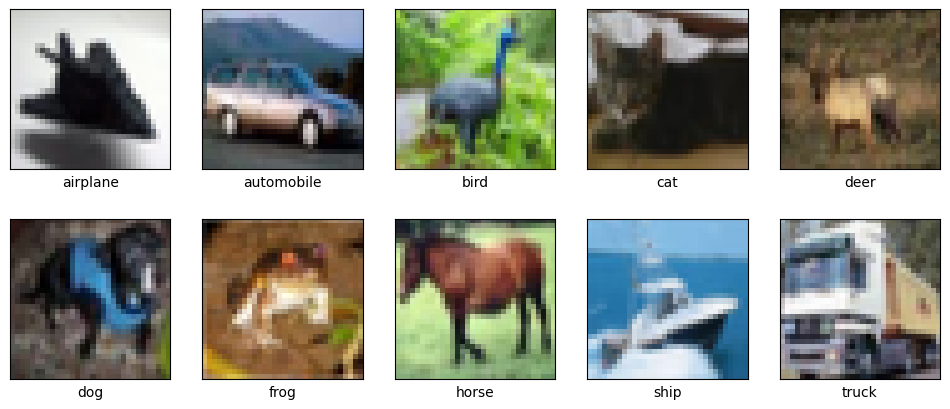

In [3]:
seen = {}
for img, label in data:
    if label not in seen:
        seen[label] = img
    if len(seen) == len(data.classes):
        break

plt.figure(figsize=(12, 5))

for i, label in enumerate(sorted(seen)):
    plt.subplot(2, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)

    plt.imshow(seen[label])
    plt.xlabel(data.classes[label])

plt.show()

    - Transforms used:
        - Random Crop
        Image is padded with 4 pixels on every side
        Crops the images in random position
        Padding provides more space as the input image is 32 pixels as well

        - Random Horizontal Flip
        Flips the images horizontally randomly

        - To Tensor
        Converts images from their file formats to a tensor
        Centers the inputs of every channel in [0, 1]
        
        - Normalisation
        Centres each channel on zero and scales it to roughly unit variance
        Mean: [0.4914, 0.4822, 0.4465]
        std: [0.2023, 0.1994, 0.2010]

2. Model Related Questions
    - What is an optimiser?
    An optimiser is an algorithm that changes the model's trainable parameters to reach the minima

    - What is the initial learning rate? 
    0.1


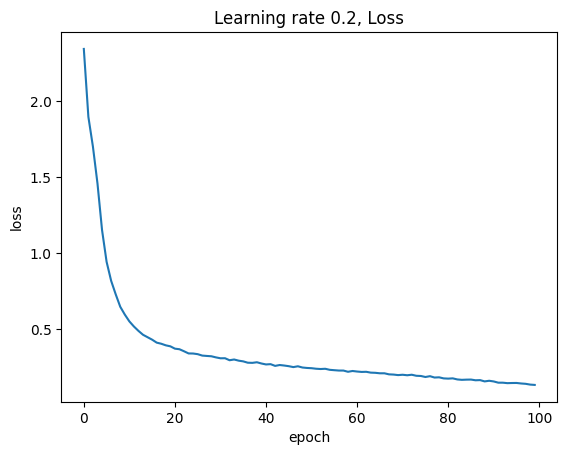

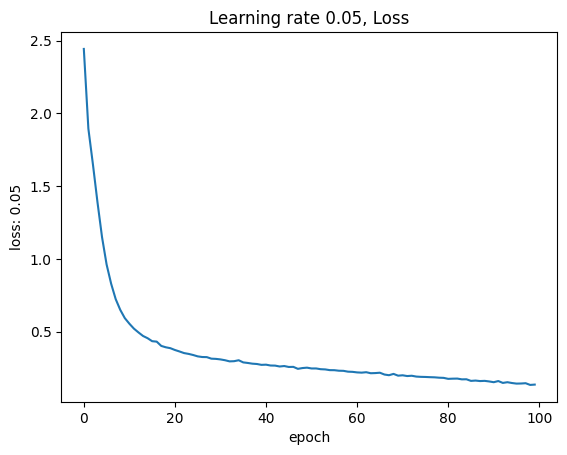

In [4]:
# Higher Learning rate plot (.2)
loss_2 = [2.3443104248809816, 1.8974663634490967, 1.7008991932678224, 1.4584871068572998, 1.15264629737854, 0.9434970304870606, 0.8183057822227479, 0.7296010983657837, 0.6475888374137878, 0.5961553018951417, 0.5513934293174744, 0.5177042192840576, 0.48878628856658934, 0.46329310868263246, 0.4472114266681671, 0.43107651233673094, 0.4116475819015503, 0.40428345534324645, 0.3938885828018188, 0.3872822688484192, 0.37199072689056395, 0.3681731326675415, 0.3548052696418762, 0.3405563649702072, 0.3400046612739563, 0.33580037556648257, 0.3264249518966675, 0.3240486881160736, 0.3219337458229065, 0.31458822801589964, 0.3086784364748001, 0.3089682671546936, 0.29580693333625796, 0.30069102605819703, 0.29301732810974124, 0.2883046615028381, 0.27950097272872926, 0.2785652102470398, 0.2825371268844605, 0.27434162239074705, 0.2681122314834595, 0.2700433407688141, 0.25863425997257233, 0.2643446447992325, 0.2609540015411377, 0.25664792116165164, 0.2506707271051407, 0.2560185233592987, 0.24793475716590882, 0.24500881930828095, 0.24339865386009216, 0.2398693491744995, 0.23801306570053102, 0.2396060122203827, 0.23274419743537902, 0.2302656537437439, 0.2279655722427368, 0.22786363467216492, 0.2198470961380005, 0.22507158568382263, 0.22151717562675477, 0.2188693335723877, 0.21974871260643006, 0.21422750940322877, 0.2130664362382889, 0.20988943645477295, 0.20989676244735717, 0.20295295676708222, 0.20148246173858642, 0.19801645939826965, 0.20025687180519103, 0.19698131509304045, 0.20038849863529204, 0.19354598223209382, 0.19216537414073945, 0.18550170108318328, 0.19091495653629303, 0.1819540568256378, 0.18343304839611055, 0.17633669308185576, 0.17484607751846312, 0.1765787494945526, 0.16949125212669372, 0.1668270568060875, 0.16812141461372376, 0.16859097448825835, 0.16395813380241395, 0.16506070609092713, 0.15655154236316682, 0.16067978855609893, 0.1561821997642517, 0.14813355006098747, 0.1480558711671829, 0.14501886298656463, 0.14593889750480651, 0.1462869548892975, 0.1429093249940872, 0.14064367003917694, 0.1355649600982666, 0.13337238720417022]
loss_05 = [2.4423107762145997, 1.894320661239624, 1.6488703950881958, 1.3886799215316772, 1.1487654730606078, 0.9614814397811889, 0.8290133051300049, 0.7231530732917786, 0.6495861071777344, 0.5927998250770569, 0.5546188562965393, 0.520616142463684, 0.49455247133255004, 0.4702520517539978, 0.4548936056900024, 0.43438922967910765, 0.43138995651245116, 0.4019891391372681, 0.3925147954750061, 0.3863337982940674, 0.3739459971237183, 0.3638204514598846, 0.3527604532051086, 0.34711593235969546, 0.3395030776500702, 0.3301495329475403, 0.3256500987815857, 0.32496265340805053, 0.3143482249355316, 0.312852675037384, 0.30921794613838194, 0.30358978635787964, 0.2957633583641052, 0.2970137660932541, 0.3035044130897522, 0.28867439260482786, 0.28486920531749726, 0.2799701501750946, 0.27771500250816344, 0.2718249546527863, 0.27308494379520415, 0.26727671414375304, 0.26663307475090026, 0.26057808264732363, 0.26373671387672426, 0.2573140127944946, 0.25800750540733336, 0.24443026525497435, 0.24983517711639405, 0.25249861799240114, 0.24702835165977477, 0.24711356566667556, 0.2419761752510071, 0.24048679988384247, 0.2355358128929138, 0.23516403607845307, 0.23151759252548218, 0.23072022340774537, 0.22503850122451782, 0.22376115236282348, 0.21994220715522766, 0.21829674325942994, 0.22126266423225402, 0.2142528147172928, 0.21537184401512147, 0.21777732232570648, 0.20535202571868896, 0.20067227461338044, 0.20964241468429565, 0.19754769409179687, 0.20010607183933257, 0.19490857939243317, 0.19696994285583497, 0.1912736830997467, 0.1894203950214386, 0.1886343939638138, 0.18716668124437333, 0.18615304827690124, 0.18361551177978516, 0.18240084145784377, 0.17567385064601898, 0.17694553013801576, 0.17751395910263063, 0.17221613971233368, 0.17277089760065079, 0.16168998639583587, 0.16385251550674437, 0.16045528810024262, 0.1618556336736679, 0.15780871995925902, 0.1526158337879181, 0.16053810254096984, 0.14772277486801147, 0.1526209981250763, 0.1470458189868927, 0.1430086118555069, 0.14365535144329072, 0.14569929442882537, 0.133954247879982, 0.13622043312311172]

plt.plot(loss_2)
plt.title('Learning rate 0.2, Loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.show()

plt.plot(loss_05)
plt.title('Learning rate 0.05, Loss')
plt.ylabel('loss: 0.05')
plt.xlabel('epoch')

plt.show()

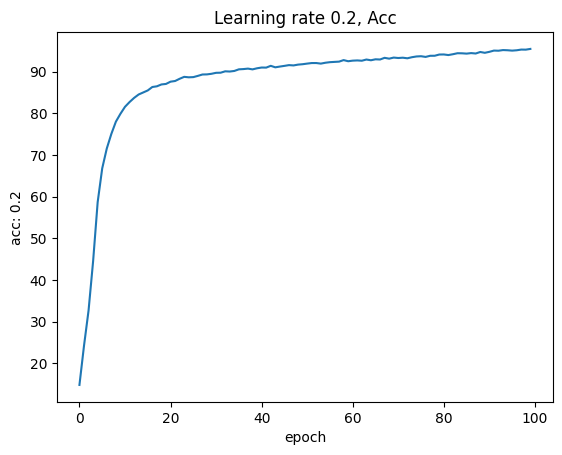

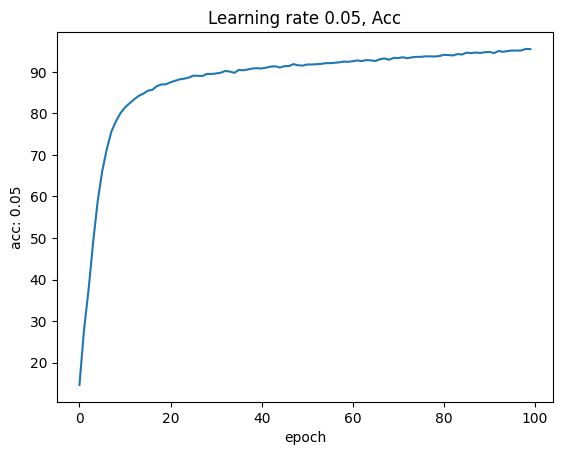

In [5]:
# Lower Learning rate plot (0.05)
acc_2 = [14.802000000000001, 24.198, 32.662, 44.492, 58.668, 66.786, 71.538, 75.036, 77.988, 79.878, 81.552, 82.692, 83.692, 84.512, 84.99600000000001, 85.482, 86.30600000000001, 86.47200000000001, 86.92, 87.042, 87.586, 87.746, 88.28200000000001, 88.744, 88.632, 88.68, 88.976, 89.306, 89.334, 89.48, 89.712, 89.738, 90.072, 90.02, 90.158, 90.546, 90.608, 90.72, 90.538, 90.8, 90.98, 90.962, 91.388, 91.02799999999999, 91.212, 91.376, 91.55799999999999, 91.484, 91.67999999999999, 91.776, 91.92399999999999, 92.05600000000001, 92.05799999999999, 91.92, 92.13, 92.266, 92.33200000000001, 92.396, 92.762, 92.49199999999999, 92.632, 92.684, 92.61399999999999, 92.9, 92.72399999999999, 92.95400000000001, 92.906, 93.31, 93.11, 93.368, 93.264, 93.338, 93.19800000000001, 93.45599999999999, 93.636, 93.692, 93.528, 93.798, 93.806, 94.098, 94.116, 93.974, 94.174, 94.41199999999999, 94.394, 94.318, 94.44399999999999, 94.346, 94.71000000000001, 94.514, 94.746, 95.048, 95.014, 95.17, 95.126, 95.038, 95.122, 95.288, 95.272, 95.446]
acc_05 = [14.628, 27.858, 37.544, 48.922, 58.828, 66.098, 71.39, 75.58, 78.082, 80.05799999999999, 81.448, 82.434, 83.38799999999999, 84.202, 84.75399999999999, 85.45, 85.678, 86.58, 86.978, 87.014, 87.502, 87.858, 88.20400000000001, 88.358, 88.62400000000001, 89.094, 89.05199999999999, 89.006, 89.50200000000001, 89.492, 89.622, 89.79599999999999, 90.218, 90.094, 89.762, 90.476, 90.38199999999999, 90.59, 90.814, 90.896, 90.816, 91.024, 91.262, 91.348, 91.048, 91.38199999999999, 91.40599999999999, 91.86800000000001, 91.60000000000001, 91.512, 91.78399999999999, 91.77199999999999, 91.854, 91.918, 92.092, 92.11200000000001, 92.182, 92.294, 92.476, 92.43, 92.58, 92.756, 92.604, 92.848, 92.75999999999999, 92.628, 93.05, 93.23, 92.92399999999999, 93.372, 93.33399999999999, 93.524, 93.284, 93.508, 93.614, 93.624, 93.734, 93.744, 93.694, 93.816, 94.098, 94.042, 93.95599999999999, 94.282, 94.188, 94.626, 94.514, 94.664, 94.548, 94.738, 94.814, 94.528, 95.018, 94.836, 95.016, 95.15400000000001, 95.122, 95.146, 95.528, 95.486]

plt.plot(acc_2)
plt.title('Learning rate 0.2, Acc')
plt.ylabel('acc: 0.2')
plt.xlabel('epoch')
plt.show()

plt.plot(acc_05)
plt.title('Learning rate 0.05, Acc')
plt.ylabel('acc: 0.05')
plt.xlabel('epoch')
plt.show()

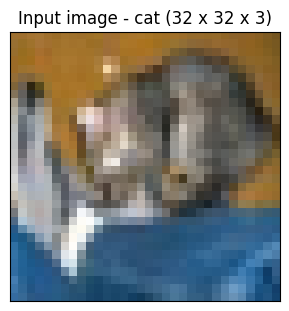

In [6]:
# Input image plot
import sys

import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

sys.path.append('VGG_cifar10_lab1')
from models.vgg import VGG

# Same normalisation constants as transform_test in main.py
MEAN = (0.4914, 0.4822, 0.4465)
STD = (0.2023, 0.1994, 0.2010)

tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])
testset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=tf)

img, label = testset[0]
x = img.unsqueeze(0)          # (1, 3, 32, 32) - a batch of one


def denormalize(t):
    """Undo Normalize so the image can be displayed."""
    m = torch.tensor(MEAN).view(3, 1, 1)
    s = torch.tensor(STD).view(3, 1, 1)
    return (t * s + m).clamp(0, 1)


plt.figure(figsize=(3.5, 3.5))
plt.imshow(denormalize(img).permute(1, 2, 0))
plt.title(f'Input image - {testset.classes[label]} (32 x 32 x 3)')
plt.xticks([])
plt.yticks([])
plt.show()

In [7]:
net = VGG('VGG16')

ckpt = torch.load('ckpt.pth', map_location='cpu', weights_only=False)
state = {k.replace('module.', ''): v for k, v in ckpt['net'].items()}
net.load_state_dict(state)
net.eval()
print(f"checkpoint: epoch {ckpt['epoch']}, test acc {ckpt['acc']:.2f}%")

# conv1 = first conv, conv8 = intermediate, conv13 = last conv
LAYERS = {'conv1': 0, 'conv8': 24, 'conv13': 40}

maps = {}
hooks = [net.features[i].register_forward_hook(
             lambda m, inp, out, n=n: maps.__setitem__(n, out.detach()))
         for n, i in LAYERS.items()]

with torch.no_grad():
    net(x)

for h in hooks:
    h.remove()

for n, t in maps.items():
    print(n, tuple(t.shape))


def show_maps(name, n_show=3):
    fm = maps[name][0]
    c, h, w = fm.shape
    fig, axes = plt.subplots(1, n_show, figsize=(3.2 * n_show, 3.4))
    for j, ax in enumerate(axes):
        ax.imshow(fm[j], cmap='viridis', interpolation='nearest')
        ax.set_title(f'{name} - channel {j}')
        ax.set_xticks([])
        ax.set_yticks([])
    fig.suptitle(f'{name} feature maps ({c} x {h} x {w})')
    plt.show()

checkpoint: epoch 98, test acc 87.65%
conv1 (1, 64, 32, 32)
conv8 (1, 512, 4, 4)
conv13 (1, 512, 2, 2)


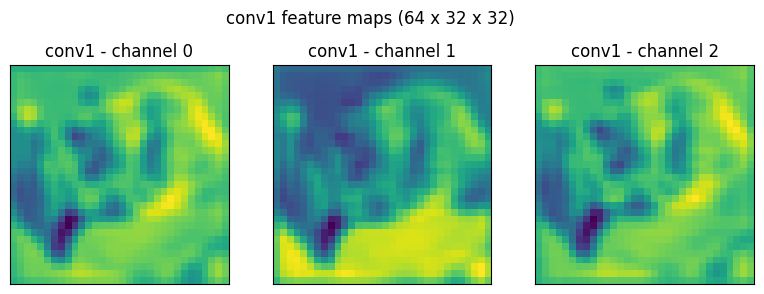

In [8]:
# First Layer Feature Maps (3)
# conv1, index 0 in net.features -> 64 x 32 x 32
show_maps('conv1')

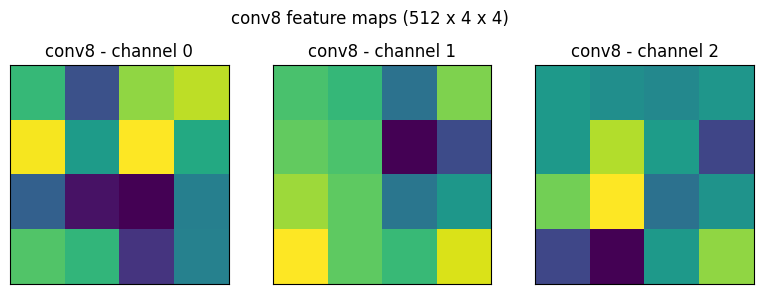

In [9]:
# Layer 8 Feature Map
# conv8, index 24 in net.features -> 512 x 4 x 4
show_maps('conv8')

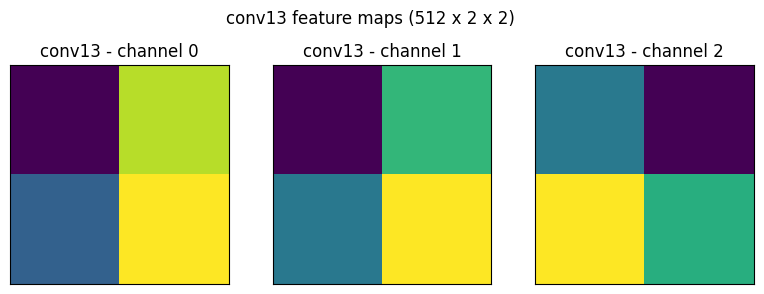

In [10]:
# Last layer feature Map
# conv13, index 40 in net.features -> 512 x 2 x 2
show_maps('conv13')